In [5]:
import pandas as pd
import numpy as np
import os
from utils.constants import chamber_levels_complete, chamber_list_complete_dict
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import itertools as it
from utils.analysis import vert_interp

In [6]:
year_range = range(2015, 2022)
plot_list = list(chamber_levels_complete.keys())
prefix_list = ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']
ens_list = [None, 3067, 1485, 1944]
name_list = ['ELM$_{default}$', 'ELM$_{default,optim}$',
             'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$']
color_list = ['#1b249e', '#05dbfc', '#ffa500', '#ff0000']

variable = 'SMIN_NH4'
#variable = 'F_NIT'
#variable = 'DENIT'

sims_data = pd.DataFrame(np.nan,
                         columns = pd.MultiIndex.from_product([name_list, plot_list]),
                         index = pd.date_range('2015-01-01', '2021-12-31', freq = '1MS'))

for name, prefix, ensemble_id in zip(name_list, prefix_list, ens_list):
    for plot in plot_list:
        if not "UQ" in prefix:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                                f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run') 
            file = os.path.join(rundir, 
                                f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC.elm.h0.2015-02-01-00000.nc')
            file2 = os.path.join(rundir, 
                                f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC.elm.h0.2020-02-01-00000.nc')
        else:
            temp = f'P{plot}'
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'g{ensemble_id:05d}', 
                                f'{chamber_list_complete_dict[temp]}')
            file = os.path.join(rundir, 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h0.2015-02-01-00000.nc')
            file2 = os.path.join(rundir, 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h0.2020-02-01-00000.nc')
        hr = Dataset(file)
        part_1 = hr[variable][:, 0] * 0.64 + hr[variable][:, 1] * 0.36
        hr.close()

        hr = Dataset(file2)
        part_2 = hr[variable][:24, 0] * 0.64 + hr[variable][:24, 1] * 0.36
        hr.close()

        sims_data.loc[:, (name, plot)] = np.concatenate([part_1.data, part_2.data])

In [7]:
# chamberwise average over all years
# gN m-2 s-1 to gN m-2 year-1
if variable == 'SMIN_NH4':
    sims_data_avg = sims_data.mean(axis = 0).unstack().T
else:
    sims_data_avg = sims_data.mean(axis = 0).unstack().T * 365 * 24 * 3600
sims_data_avg.index = [chamber_list_complete_dict[f'P{plot}'] for plot in sims_data_avg.index]
sims_data_avg = sims_data_avg.sort_index(axis = 0).loc[:, name_list]
sims_data_avg = pd.concat([sims_data_avg.iloc[[-1], :], sims_data_avg.iloc[:-1, :]], axis = 0)

[Text(0, 0, 'TAMB'),
 Text(1, 0, 'T0.00'),
 Text(2, 0, 'T0.00CO2'),
 Text(3, 0, 'T2.25'),
 Text(4, 0, 'T2.25CO2'),
 Text(5, 0, 'T4.50'),
 Text(6, 0, 'T4.50CO2'),
 Text(7, 0, 'T6.75'),
 Text(8, 0, 'T6.75CO2'),
 Text(9, 0, 'T9.00'),
 Text(10, 0, 'T9.00CO2')]

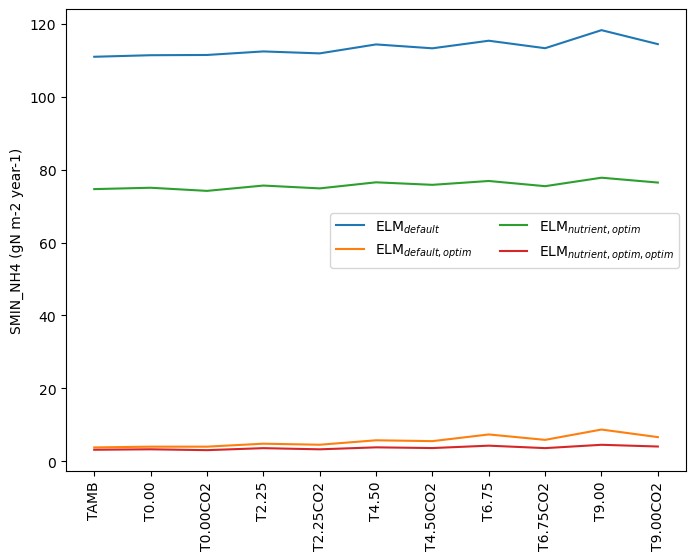

In [9]:
fig, ax = plt.subplots(figsize = (8, 6))
sims_data_avg.plot(ax = ax, legend = False)
if variable == 'SMIN_NH4':
    ax.set_ylabel(f'{variable} (gN m-2 year-1)')
else:
    ax.set_ylabel(f'{variable} (gN m-2)')
ax.legend(ncol = 2)
ax.set_xticks(range(sims_data_avg.shape[0]))
ax.set_xticklabels(sims_data_avg.index, rotation = 90)